In [154]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [155]:
# loading data
filepath = os.path.join(os.path.abspath(".."), "data", "car_fuel_efficiency_2026.csv")
columns = ["engine_displacement", "horsepower", "vehicle_weight", "model_year", "fuel_efficiency_mpg"]
df = pd.read_csv(filepath, usecols=columns)
df.head()

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
0,2006,2180,243.0,3870,31.9
1,2008,2390,272.0,4210,31.3
2,1996,2320,267.0,4240,27.5
3,1989,2130,258.0,4490,28.5
4,1994,2580,304.0,4510,31.0


In [156]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   engine_displacement  10000 non-null  int64  
 2   horsepower           9123 non-null   float64
 3   vehicle_weight       10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


In [157]:
df.describe()

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
count,10000.000000,10000.000000,9123.000000,10000.000000,10000.000000
mean,1999.549500,2268.807000,254.446016,4286.754000,29.997700
std,14.207925,183.447355,22.844613,266.212491,2.930245
min,1975.000000,1590.000000,171.000000,3320.000000,19.800000
25%,1987.000000,2150.000000,239.000000,4110.000000,28.000000
50%,2000.000000,2270.000000,254.000000,4280.000000,30.000000
75%,2012.000000,2390.000000,270.000000,4470.000000,31.900000
max,2024.000000,3110.000000,334.000000,5460.000000,41.200000


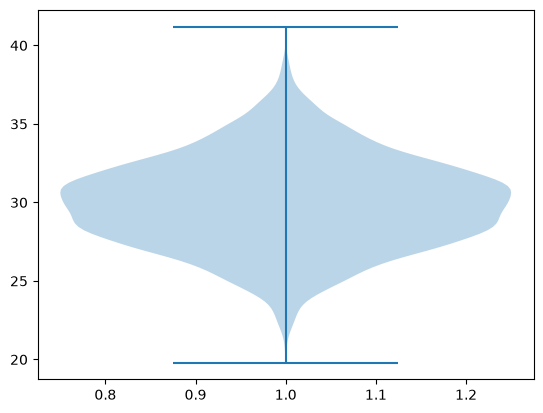

In [158]:
plt.violinplot(df.fuel_efficiency_mpg);

In [159]:
# splitting the dataset
n = len(df)
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

# resetting the index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.shape, df_val.shape, df_test.shape, df.shape

((6000, 5), (2000, 5), (2000, 5), (10000, 5))

In [160]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           6000 non-null   int64  
 1   engine_displacement  6000 non-null   int64  
 2   horsepower           5462 non-null   float64
 3   vehicle_weight       6000 non-null   int64  
 4   fuel_efficiency_mpg  6000 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 234.5 KB


In [161]:
def prepare(original, x):
    df = original.copy()
    df.horsepower = df.horsepower.fillna(x)
    # print(df.info())
    X_train = df.drop(columns="fuel_efficiency_mpg").values
    y_train = df.fuel_efficiency_mpg.values
    return X_train, y_train

In [162]:
# preparing data from 0
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           6000 non-null   int64  
 1   engine_displacement  6000 non-null   int64  
 2   horsepower           5462 non-null   float64
 3   vehicle_weight       6000 non-null   int64  
 4   fuel_efficiency_mpg  6000 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 234.5 KB


In [163]:
X_train, y_train = prepare(df_train, 0.0)
X_val, y_val = prepare(df_val, 0.0)
X_train, y_train, X_val, y_val

(array([[2015., 1900.,  239., 3790.],
        [1992., 2000.,  224., 4380.],
        [2022., 2330.,  286., 4090.],
        ...,
        [1989., 2240.,  255., 4190.],
        [2020., 2430.,  254., 4280.],
        [1996., 2390.,  266., 4220.]], shape=(6000, 4)),
 array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,)),
 array([[2004., 2240.,  265., 3990.],
        [2019., 2390.,  259., 4770.],
        [2018., 2360.,  265., 4320.],
        ...,
        [2017., 2390.,  264., 4550.],
        [2014., 2330.,  244., 4440.],
        [2021., 2170.,  260., 4460.]], shape=(2000, 4)),
 array([30.4, 32.8, 27.8, ..., 30.6, 31. , 30.8], shape=(2000,)))

In [164]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           6000 non-null   int64  
 1   engine_displacement  6000 non-null   int64  
 2   horsepower           5462 non-null   float64
 3   vehicle_weight       6000 non-null   int64  
 4   fuel_efficiency_mpg  6000 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 234.5 KB


In [165]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r*np.eye(XTX.shape[0])
    if r == 0.0:
        XTX_inv = np.linalg.pinv(XTX)
    else:
        XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

In [166]:
def rmse(y_pred, y):
    error = y_pred - y
    se = error**2
    mse = se.mean()
    return np.sqrt(mse)

In [167]:
b, w = train_linear_regression_reg(X_train, y_train, 0.0)
b, w

(np.float64(-153.88496080440484),
 array([ 1.02146784e-01, -1.51505520e-03, -4.74021361e-06, -3.95418397e-03]))

In [168]:
# with 0.0
y_pred = b + X_val.dot(w)
round(rmse(y_pred, y_val), 3)

np.float64(2.205)

In [169]:
# with mean
x = df_train.horsepower.mean()
X_train, y_train = prepare(df_train, x)
X_val, y_val = prepare(df_val, x)

b, w = train_linear_regression_reg(X_train, y_train, 0.0)
y_pred = b + X_val.dot(w)
round(rmse(y_pred, y_val), 3)

np.float64(2.202)

In [170]:
X_train, y_train = prepare(df_train, 0.0)
X_val, y_val = prepare(df_val, 0.0)
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    print('-------------------------------------------------')
    print(f'r: {r}')
    b, w = train_linear_regression_reg(X_train, y_train, r)
    y_pred = b + X_val.dot(w)
    print(f'rmse: {round(rmse(y_pred, y_val), 4)}')

-------------------------------------------------
r: 0
rmse: 2.2053
-------------------------------------------------
r: 0.01
rmse: 2.2058
-------------------------------------------------
r: 0.1
rmse: 2.2241
-------------------------------------------------
r: 1
rmse: 2.3492
-------------------------------------------------
r: 5
rmse: 2.4094
-------------------------------------------------
r: 10
rmse: 2.4195
-------------------------------------------------
r: 100
rmse: 2.4292


In [171]:
# splitting the dataset
def split(seed):
    n = len(df)
    n_val = int(n*0.2)
    n_test = int(n*0.2)
    n_train = n - n_val - n_test
    
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]
    
    # resetting the index
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    return df_train, df_val, df_test

In [172]:
scores = []
for seed in range(10):
    print('-----------------------------------------------------')
    print(f'seed: {seed}')
    df_train, df_val, _ = split(seed)
    X_train, y_train = prepare(df_train, 0.0)
    X_val, y_val = prepare(df_train, 0.0)
    b, w = train_linear_regression_reg(X_train, y_train, 0.0)
    y_pred = b + X_val.dot(w)
    score = rmse(y_pred, y_val)
    scores.append(score)
    print(f'rmse: {score}')
print(f'rmse_scores: {scores}')
std = np.std(scores)
print(f'std: {round(std, 3)}')

-----------------------------------------------------
seed: 0
rmse: 2.201392183182576
-----------------------------------------------------
seed: 1
rmse: 2.2036770024341137
-----------------------------------------------------
seed: 2
rmse: 2.2295183290873197
-----------------------------------------------------
seed: 3
rmse: 2.209005161763374
-----------------------------------------------------
seed: 4
rmse: 2.2019300328200044
-----------------------------------------------------
seed: 5
rmse: 2.192891675276539
-----------------------------------------------------
seed: 6
rmse: 2.176902296114492
-----------------------------------------------------
seed: 7
rmse: 2.2089011820049183
-----------------------------------------------------
seed: 8
rmse: 2.1974848675454366
-----------------------------------------------------
seed: 9
rmse: 2.2003514226465763
rmse_scores: [np.float64(2.201392183182576), np.float64(2.2036770024341137), np.float64(2.2295183290873197), np.float64(2.209005161763

In [178]:
df_train, df_val, df_test = split(9)
df_train = pd.concat([df_train, df_val], ignore_index=True)
X_train, y_train = prepare(df_train, 0.0)
X_test, y_test = prepare(df_test, 0.0)
b, w = train_linear_regression_reg(X_train, y_train, r=0.001)
y_pred = b + X_test.dot(w)
round(rmse(y_pred, y_test), 3)

np.float64(2.236)